In [20]:
from gensim.models import KeyedVectors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [4]:
import gensim.downloader
print(list(gensim.downloader.info()['models'].keys()))

gensim.downloader.load("word2vec-google-news-300")
gensim.downloader.load("glove-wiki-gigaword-300")

In [12]:
# Path to the pretrained model
path = "~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz"

# Load the model
model = KeyedVectors.load_word2vec_format(path, binary=True)

In [13]:
with open("/sailhome/jjian/projects/abstraction/data/ditransitives.txt", "r") as f:
    ditransitives = f.readlines()

with open("/sailhome/jjian/projects/abstraction/data/motion.txt", "r") as f:
    motion = f.readlines()

ditransitives = [x.strip() for x in ditransitives]
motion = [x.strip() for x in motion]

In [54]:
import lemminflect

def get_inflections(word):
    infl = lemminflect.getAllInflections(word)
    return [x[0] for x in infl.values()]

ditransitives_inflections = []
for word in ditransitives:
    ditransitives_inflections.extend(get_inflections(word))

motion_inflections = []
for word in motion:
    motion_inflections.extend(get_inflections(word))
    

In [55]:
motion_inflections

['descended',
 'descending',
 'descends',
 'descend',
 'descend',
 'hops',
 'hop',
 'hopped',
 'hopping',
 'hops',
 'hop',
 'hop',
 'canoes',
 'canoe',
 'canoed',
 'canoeing',
 'canoes',
 'canoe',
 'canoe',
 'staggers',
 'stagger',
 'staggered',
 'staggering',
 'staggers',
 'stagger',
 'stagger',
 'inches',
 'inch',
 'inched',
 'inching',
 'inches',
 'inch',
 'inch',
 'darts',
 'dart',
 'darted',
 'darting',
 'darts',
 'dart',
 'dart',
 'scurry',
 'scurried',
 'scurrying',
 'scurries',
 'scurry',
 'scurry',
 'treks',
 'trek',
 'trekked',
 'trekking',
 'treks',
 'trek',
 'trek',
 'vaults',
 'vault',
 'vaulted',
 'vaulting',
 'vaults',
 'vault',
 'vault',
 'trudges',
 'trudge',
 'trudged',
 'trudging',
 'trudges',
 'trudge',
 'trudge',
 'ascended',
 'ascending',
 'ascends',
 'ascend',
 'ascend',
 'go',
 'go',
 'went',
 'gone',
 'going',
 'goes',
 'go',
 'go',
 'runs',
 'run',
 'ran',
 'run',
 'running',
 'runs',
 'run',
 'run',
 'hikes',
 'hike',
 'hiked',
 'hiking',
 'hikes',
 'hike',
 

In [42]:
# get vectors for both ditransitive and motion from the model

ditransitive_vectors = [model[x] for x in ditransitives if x in model]
motion_vectors = [model[x] for x in motion if x in model]

print(len(ditransitive_vectors) == len(ditransitives))
print(len(motion_vectors) == len(motion))

True
True


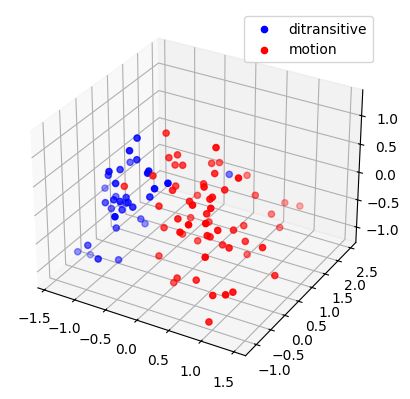

In [43]:
# run a pca then plot
pca = PCA(n_components=3)

# fit the pca
pca.fit(ditransitive_vectors + motion_vectors)

# transform the data
ditransitive_pca = pca.transform(ditransitive_vectors)
motion_pca = pca.transform(motion_vectors)

# 3D plot

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(ditransitive_pca[:, 0], ditransitive_pca[:, 1], ditransitive_pca[:, 2], c='b', label='ditransitive')
ax.scatter(motion_pca[:, 0], motion_pca[:, 1], motion_pca[:, 2], c='r', label='motion')

plt.legend()
plt.show()


In [32]:
import spacy

In [35]:
nlp = spacy.load("/sailhome/jjian/projects/abstraction/glove_vecs")


In [56]:
ditransitive_vectors = [nlp(x).vector for x in ditransitives_inflections]
motion_vectors = [nlp(x).vector for x in motion_inflections]

print(len(ditransitive_vectors) == len(ditransitives))
print(len(motion_vectors) == len(motion))

False
False


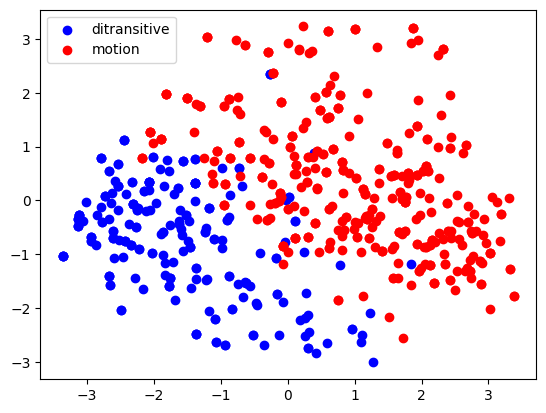

In [67]:
# plot 2D pca

# plot in 2D

pca = PCA(n_components=4)

# fit the pca
pca.fit(ditransitive_vectors + motion_vectors)

# transform the data
ditransitive_pca = pca.transform(ditransitive_vectors)
motion_pca = pca.transform(motion_vectors)

plt.scatter(ditransitive_pca[:, 0], ditransitive_pca[:, 1], c='b', label='ditransitive')
plt.scatter(motion_pca[:, 0], motion_pca[:, 1], c='r', label='motion')

plt.legend()
plt.show()

# get the average in class and between class distances before and after pca



In [68]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

# get pairwise distances excluding self distances
ditransitive_distances = euclidean_distances(ditransitive_vectors, ditransitive_vectors)
motion_distances = euclidean_distances(motion_vectors, motion_vectors)

# get the average distance within class
ditransitive_within = np.mean(ditransitive_distances[np.triu_indices(len(ditransitive_distances), k=1)])
motion_within = np.mean(motion_distances[np.triu_indices(len(motion_distances), k=1)])

# get the average distance between class
ditransitive_motion_distances = euclidean_distances(ditransitive_vectors, motion_vectors)
between = np.mean(ditransitive_motion_distances)

print(ditransitive_within, motion_within, between)

# get the average distance within class after pca
ditransitive_distances = euclidean_distances(ditransitive_pca, ditransitive_pca)
motion_distances = euclidean_distances(motion_pca, motion_pca)

# get the average distance within class
ditransitive_within = np.mean(ditransitive_distances[np.triu_indices(len(ditransitive_distances), k=1)])
motion_within = np.mean(motion_distances[np.triu_indices(len(motion_distances), k=1)])
# get the standard deviation of the distances
ditransitive_within_std = np.std(ditransitive_distances[np.triu_indices(len(ditransitive_distances), k=1)])
motion_within_std = np.std(motion_distances[np.triu_indices(len(motion_distances), k=1)])
# get the average distance between class
ditransitive_motion_distances = euclidean_distances(ditransitive_pca, motion_pca)
between = np.mean(ditransitive_motion_distances)
# get the standard deviation of the distances
between_std = np.std(ditransitive_motion_distances)


# format and print with std
print(f"Within class ditransitive: {ditransitive_within:.2f} +/- {ditransitive_within_std:.2f}")
print(f"Within class motion: {motion_within:.2f} +/- {motion_within_std:.2f}")
print(f"Between class: {between:.2f} +/- {between_std:.2f}")


7.921433 8.124406 8.531528
Within class ditransitive: 2.83 +/- 1.19
Within class motion: 3.04 +/- 1.26
Between class: 4.04 +/- 1.20


In [2]:
import json
from collections import Counter

In [6]:
ditrans_preds = json.load(open("/nlp/scr/jjian/data/wikitext/ditrans_annotated/predictions/preposition_fragment/battlestar-gpt2-small-x49.checkpoint-400000.predictions.json", "r"))
motion_preds = json.load(open("/nlp/scr/jjian/data/wikitext/motion_annotated/predictions/preposition_fragment/battlestar-gpt2-small-x49.checkpoint-400000.predictions.json", "r"))
ditrans_verbs = [x["top_k_tokens"][0][0] for x in ditrans_preds if len(x["top_k_tokens"]) > 0]
motion_verbs = [x["top_k_tokens"][0][0] for x in motion_preds if len(x["top_k_tokens"]) > 0]

In [7]:
ditrans_verbs = Counter(ditrans_verbs)
motion_verbs = Counter(motion_verbs)

In [11]:
ditrans_minus_motion = ditrans_verbs - motion_verbs
motion_minus_ditrans = motion_verbs - ditrans_verbs

In [15]:
print(ditrans_minus_motion.most_common(15))
print(motion_minus_ditrans.most_common(15))

[(' public', 123), (' children', 58), (' audience', 47), (' people', 46), (' company', 36), (' family', 36), (' New', 35), (' British', 35), (' player', 25), (' state', 23), (' team', 22), (' new', 21), (' best', 21), (' police', 21), (' world', 21)]
[(' top', 167), (' front', 112), (' surface', 100), (' United', 96), (' hospital', 88), (' scene', 61), (' ground', 52), (' door', 38), (' airport', 33), (' north', 32), (' finish', 29), (' bottom', 28), (' south', 26), (' west', 25), (' sea', 24)]


In [20]:
print(ditrans_top_verbs + motion_top_verbs)

['public', 'children', 'audience', 'people', 'company', 'family', 'New', 'British', 'player', 'state', 'team', 'new', 'best', 'police', 'world', 'top', 'front', 'surface', 'United', 'hospital', 'scene', 'ground', 'door', 'airport', 'north', 'finish', 'bottom', 'south', 'west', 'sea']


In [18]:
ditrans_top_verbs = [x[0].strip() for x in ditrans_minus_motion.most_common(15)]
motion_top_verbs = [x[0].strip() for x in motion_minus_ditrans.most_common(15)]

with open("/sailhome/jjian/projects/abstraction/data/ditrans_400000_top15.txt", "w") as f:
    f.write("\n".join(ditrans_top_verbs))

with open("/sailhome/jjian/projects/abstraction/data/motion_400000_top15.txt", "w") as f:
    f.write("\n".join(motion_top_verbs))